**Credit Risk Scorer with SHAP**

What is SHAP?     -  SHAP stands for   **SHapley Additive exPlanations**.

---

It's a method to answer onequestion that ML models are historically terrible at answering:



**"Why did the model make this specific prediction for this specific person?"**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing ( Not used these Lib )
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Train Test Split
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.metrics import accuracy_score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [2]:
data = pd.read_csv('/content/cs-training.csv')
data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
data.shape

(150000, 12)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [5]:
rename_map = {
    'Unnamed: 0': 'row_id',
    'SeriousDlqin2yrs': 'target',
    'RevolvingUtilizationOfUnsecuredLines': 'revolving_utilization',
    'NumberOfTime30-59DaysPastDueNotWorse': 'late_30_59',
    'DebtRatio': 'debt_ratio',
    'MonthlyIncome': 'monthly_income',
    'NumberOfOpenCreditLinesAndLoans': 'open_credit_lines',
    'NumberOfTimes90DaysLate': 'late_90',
    'NumberRealEstateLoansOrLines': 'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'late_60_89',
    'NumberOfDependents': 'dependents'
}
data.rename(columns=rename_map, inplace=True)

Renaming

In [6]:
data['target'].value_counts()

,count
target,
0,139974
1,10026


In [7]:
data.drop('row_id',inplace=True,axis=1)

In [8]:
data.isnull().sum()

,0
target,0
revolving_utilization,0
age,0
late_30_59,0
debt_ratio,0
monthly_income,29731
open_credit_lines,0
late_90,0
real_estate_loans,0
late_60_89,0


There are many missing values in monthly_income and dependents

### Preprocessing and Handling Missing values

In [9]:
data.head()

,target,revolving_utilization,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90,real_estate_loans,late_60_89,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [10]:
data.describe()

,target,revolving_utilization,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90,real_estate_loans,late_60_89,dependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [11]:
data.shape

(150000, 11)

In [12]:
max(data['monthly_income'])

3008750.0

In [13]:
min(data['monthly_income'])

0.0

In [14]:
np.mean(data['monthly_income'])

np.float64(6670.221237392844)

In [15]:
data.isnull().sum()

,0
target,0
revolving_utilization,0
age,0
late_30_59,0
debt_ratio,0
monthly_income,29731
open_credit_lines,0
late_90,0
real_estate_loans,0
late_60_89,0


In [16]:
np.median(data['monthly_income'])

np.float64(nan)

In [17]:
# Filling missing values using mean in monthly_income

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
data['monthly_income'] = imputer.fit_transform(data[['monthly_income']])

In [18]:
data['dependents'].unique()

array([ 2.,  1.,  0., nan,  3.,  4.,  5.,  6.,  8.,  7., 20., 10.,  9.,
       13.])

In [19]:
# fill nan value with mode in dependencies

imputer = SimpleImputer(strategy='most_frequent')
data['dependents'] = imputer.fit_transform(data[['dependents']])

In [20]:
# Coverting float to int data_type

data['dependents'] = data['dependents'].astype(int)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target                 150000 non-null  int64  
 1   revolving_utilization  150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   late_30_59             150000 non-null  int64  
 4   debt_ratio             150000 non-null  float64
 5   monthly_income         150000 non-null  float64
 6   open_credit_lines      150000 non-null  int64  
 7   late_90                150000 non-null  int64  
 8   real_estate_loans      150000 non-null  int64  
 9   late_60_89             150000 non-null  int64  
 10  dependents             150000 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 12.6 MB


In [22]:
data.duplicated().sum()

np.int64(767)

### Data visualization

In [23]:
data.head()

,target,revolving_utilization,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90,real_estate_loans,late_60_89,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0


In [24]:
data.shape

(150000, 11)

In [25]:
data.describe()

,target,revolving_utilization,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90,real_estate_loans,late_60_89,dependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.288045e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,6.600000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [26]:
# to ignore the warnings
from warnings import filterwarnings

sns.set()
filterwarnings('ignore')

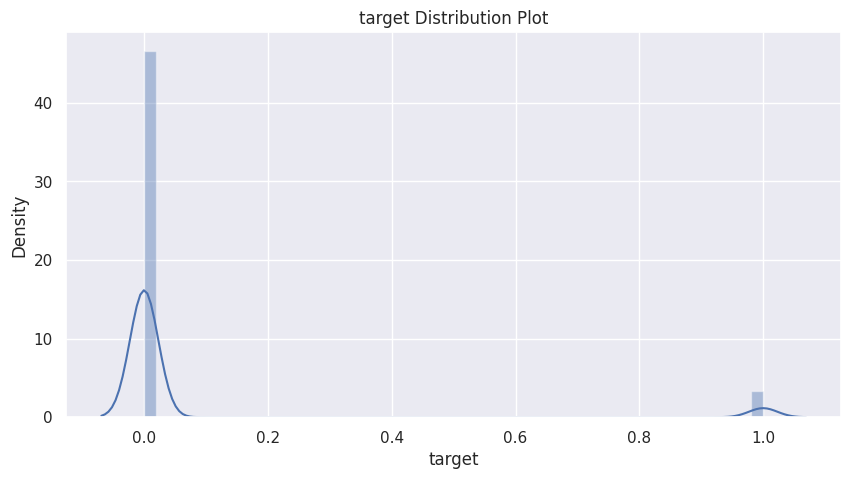

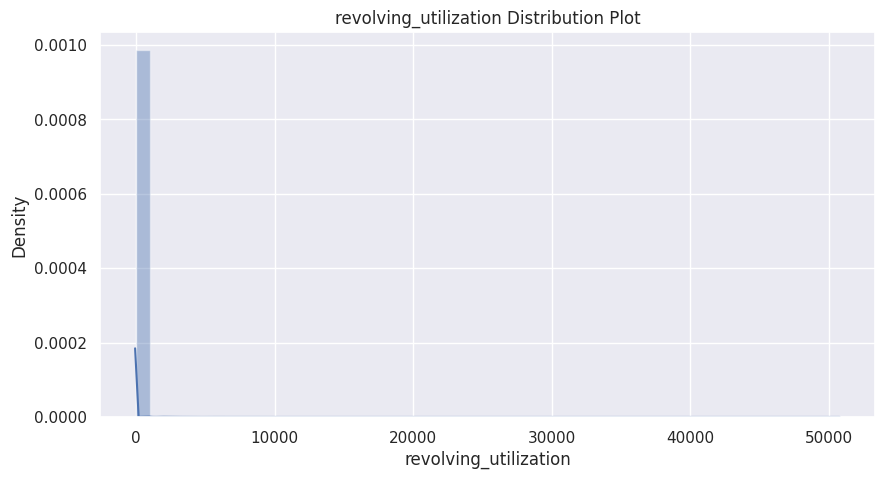

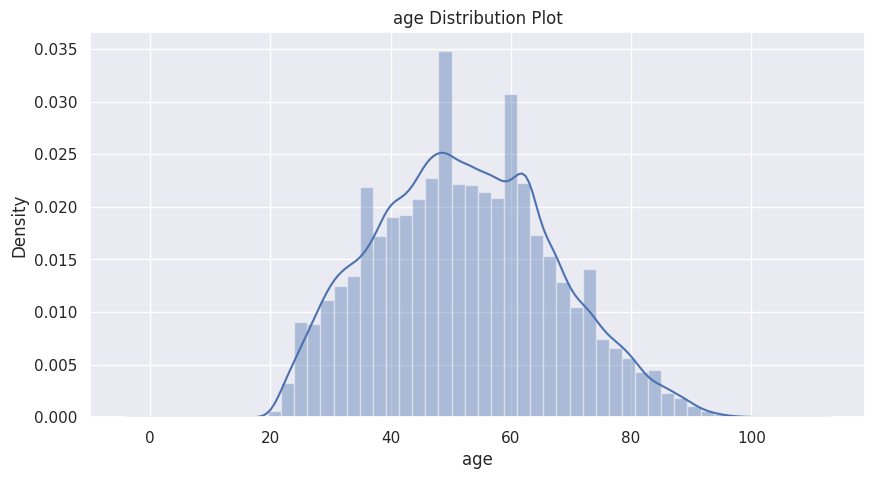

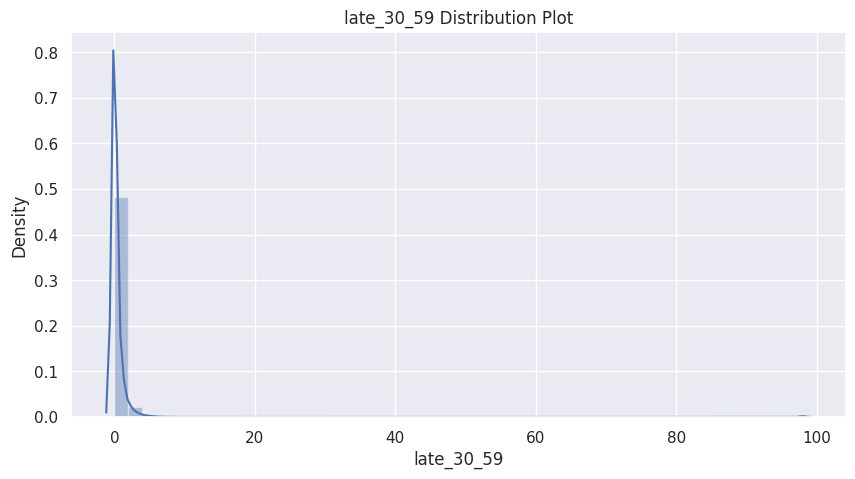

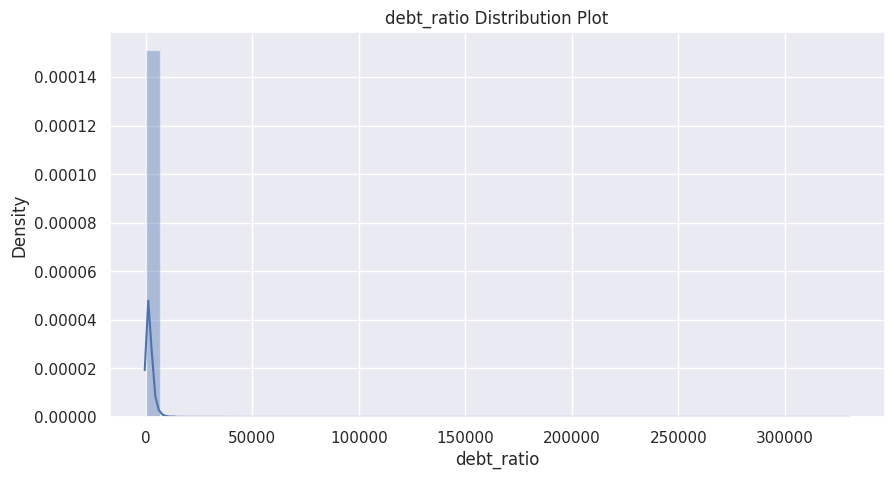

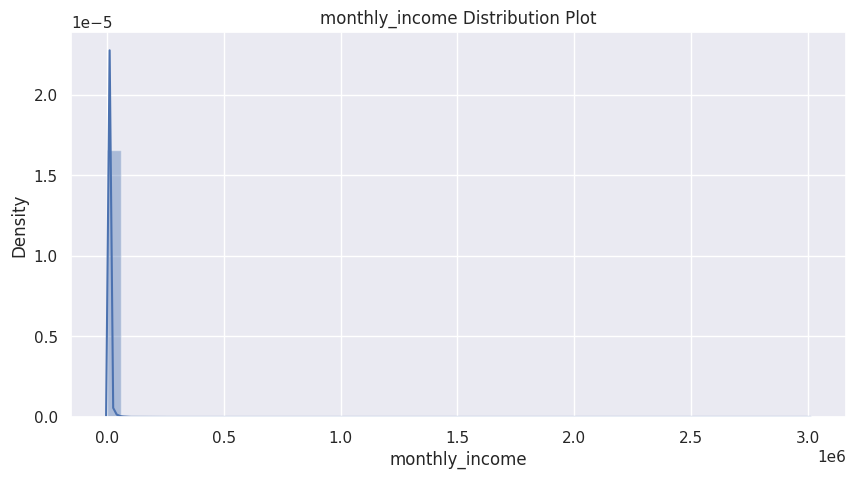

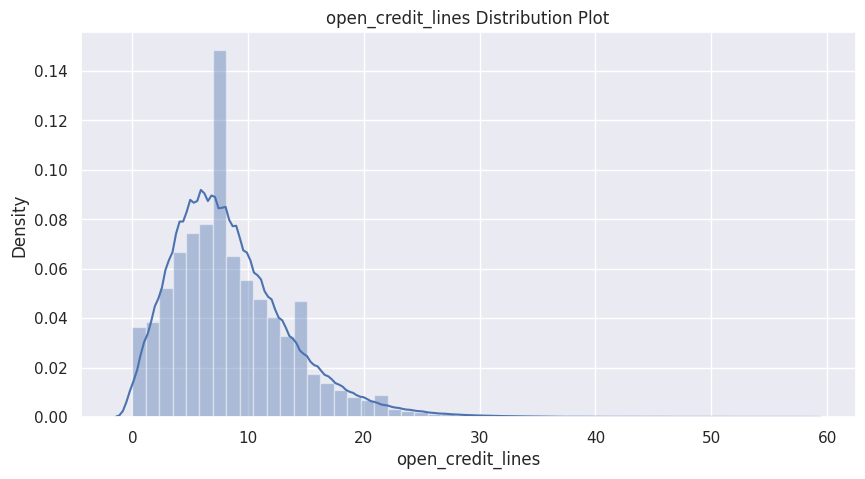

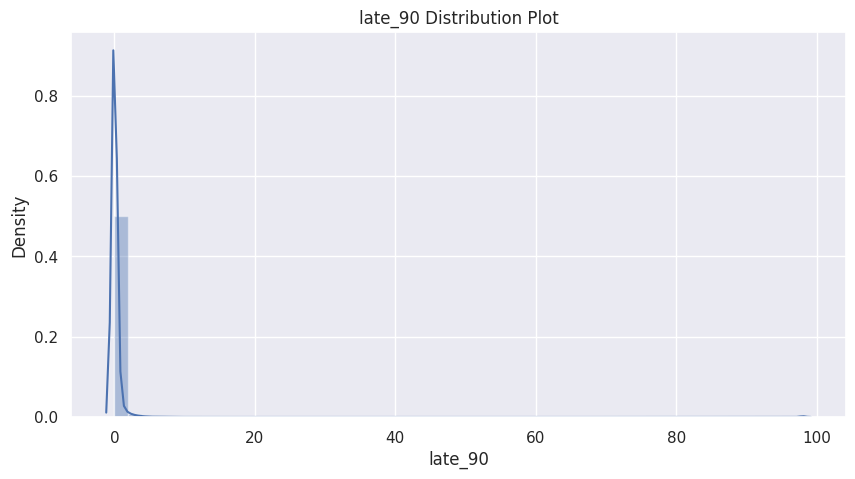

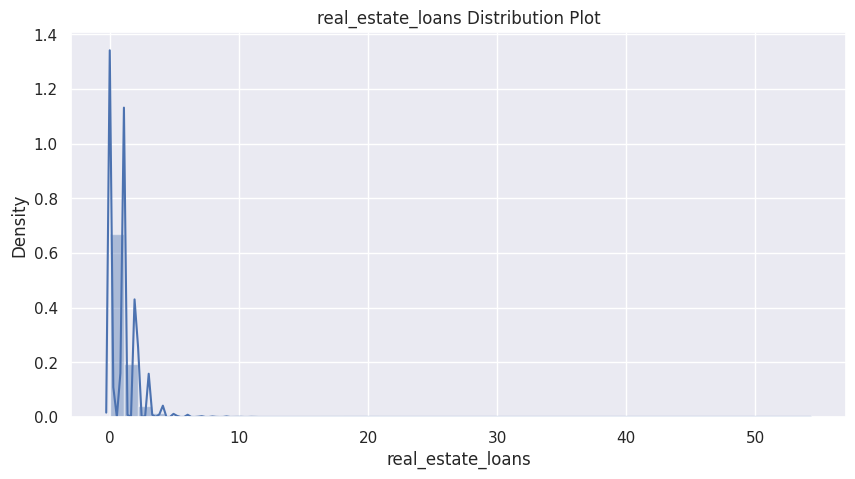

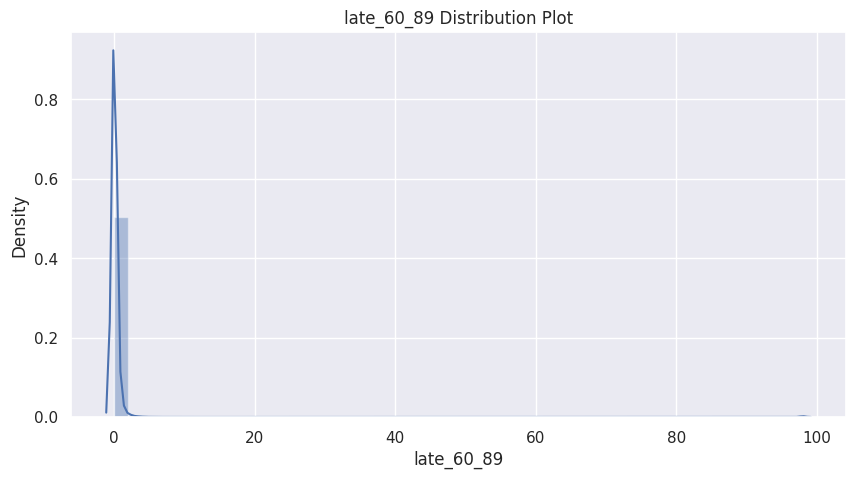

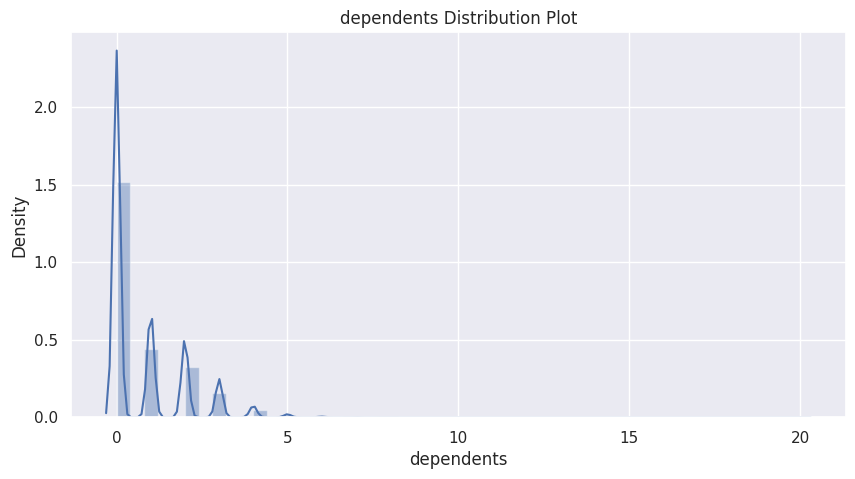

In [27]:
def distplot(data):
  for col in data.columns:
    plt.figure(figsize=(10, 5))
    sns.distplot(data[col])
    plt.title(f"{col} Distribution Plot")
    plt.show()
    print(" "*100)

distplot(data)

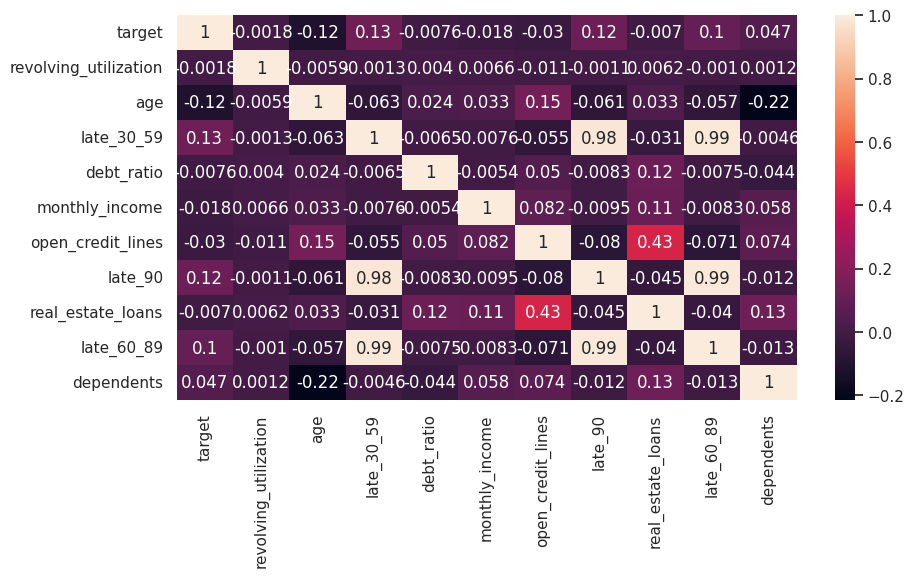

In [28]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(),annot=True)
plt.show()

When I plotted the correlation matrix, I found near-perfect multicollinearity (r ≈ 0.99) among the three late-payment features. Rather than feeding redundant signals to the model, I consolidated them — which also made the SHAP explanations cleaner and more interpretable for each distinct risk factor.

The three features are so correlated (r = 0.99) that they carry almost zero additional information beyond each other

Consolidate correlated late-payment features into a single
    severity-**weighted delinquency score.**

In [29]:
# 90-day late is more severe than 60-day, which is more severe than 30-day

data_copy = data.copy()  # never mutate the original — good practice

data_copy['delinquency_score'] = (
    data_copy['late_30_59'] * 1 +
    data_copy['late_60_89'] * 2 +
    data_copy['late_90']    * 3
)

data_copy.drop(columns=['late_30_59', 'late_60_89', 'late_90'], inplace=True)

data_copy.head()

,target,revolving_utilization,age,debt_ratio,monthly_income,open_credit_lines,real_estate_loans,dependents,delinquency_score
0,1,0.766127,45,0.802982,9120.0,13,6,2,2
1,0,0.957151,40,0.121876,2600.0,4,0,1,0
2,0,0.658180,38,0.085113,3042.0,2,0,0,4
3,0,0.233810,30,0.036050,3300.0,5,0,0,0
4,0,0.907239,49,0.024926,63588.0,7,1,0,1


Checking for Class Imbalance in target

In [30]:
data_copy["target"].value_counts()

,count
target,
0,139974
1,10026


Huge class Imbalance is seen in target  - Handle it using SMOTE

## Train Test Split

In [61]:
x = data_copy.drop('target',axis=1)
y = data_copy['target']

x.shape

(150000, 8)

In [32]:
x_train, x_test, y_train, y_test = train_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
# Shape Before
x_train.shape , y_train.shape

((120000, 8), (120000,))

In [34]:
x_test.shape,y_test.shape

((30000, 8), (30000,))

In [35]:
# To check if there are any class imbalances
print(y_train.value_counts())

target
0    111930
1      8070
Name: count, dtype: int64


Synthetic Minority Oversampling TEchnique (SMOTE)

In [36]:
# to handle imbalnces in target (y_train)
smote = SMOTE(random_state=42)

x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [37]:
# Shape After SMOTE    x_train_smote   ,   y_train_smote

x_train_smote.shape , y_train_smote.shape

((223860, 8), (223860,))

In [38]:
print(y_train_smote.value_counts())

target
0    111930
1    111930
Name: count, dtype: int64


Class Imbalance in Target Balanced Using ***SMOTE***

## Base Model ( Using imbalnce data - without using SMOTE )

In [39]:
base_model = LogisticRegression(random_state=42)
base_model.fit(x_train,y_train)


LogisticRegression(random_state=42)

In [40]:
y_pred_lr = base_model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred_lr)
print("Test Accuracy : ",accuracy)

print(" ")

confusion = confusion_matrix(y_test,y_pred_lr)
print("Confusion Matrix : ")
print(confusion)

print(" "*20)

print("Classification Report : ")
print(classification_report(y_test,y_pred_lr))

Test Accuracy :  0.9346666666666666
 
Confusion Matrix : 
[[28020    24]
 [ 1936    20]]
                    
Classification Report : 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     28044
           1       0.45      0.01      0.02      1956

    accuracy                           0.93     30000
   macro avg       0.69      0.50      0.49     30000
weighted avg       0.90      0.93      0.90     30000



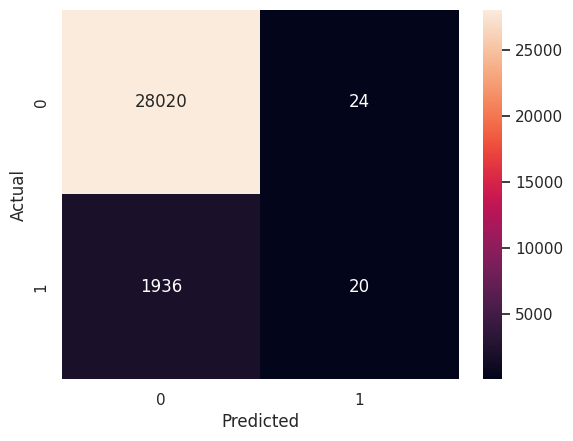

In [41]:
plt.figure9figsize=(10,5)
sns.heatmap(confusion,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

High accuracy on imbalanced data is meaningless. A model that predicts "no default" for every single person would also score 93%

-  93% accuracy, but class 1 recall = 0.01.
- Out of 1,956 actual defaulters, the model caught only 20. It missed 1,936.


# Model Training




*   Split the dataset into ( Train , test ) Already done
  

*   compare CV scores of models ( only on training set ) with default parameters
*   Select Best model with consistent CV scores
*   Tune hyper paramets using GRID SEARCH CV ( Not done )
*   Train Model








In [42]:
models ={
    "LogisticRegression" : LogisticRegression(random_state=42),
    "RandomForestClassifier" : RandomForestClassifier(random_state=42),
    "DecisionTreeClassifier" : DecisionTreeClassifier(random_state=42),
    "AdaBoostClassifier" : AdaBoostClassifier(random_state=42),
    "XGBoost" : XGBClassifier(random_state=42)
}

In [43]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, scale_pos_weight=13.9, eval_metric='logloss')
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f"{name} → AUC: {scores.mean():.4f}  \t\t STD : {scores.std():.4f}")

LogisticRegression → AUC: 0.7914  		 STD : 0.0050
RandomForest → AUC: 0.8390  		 STD : 0.0027
XGBoost → AUC: 0.8460  		 STD : 0.0044


In [44]:
# WHY WE DIDN'T USE SMOTE HERE

# Our class imbalance is 93:7 — moderate, not extreme.

# SMOTE generates fake synthetic data to balance classes.
# But RandomForest and XGBoost don't need fake data —
# they have built-in parameters to handle imbalance :
#
#   class_weight='balanced'  →  RandomForest, LogisticRegression
#   scale_pos_weight=13.9    →  XGBoost  (= 111930 / 8070)
#
# These tell the model: "penalise missing a defaulter ~14x more."
# Same effect as SMOTE, but cleaner — no synthetic noise, no leakage risk.
#
# SMOTE is only justified when:
#   1. Imbalance is extreme (99:1 or worse), AND
#   2. class_weight still gives poor minority class recall


In [45]:
cv_results

{'LogisticRegression': array([0.78567295, 0.7920444 , 0.79161796, 0.80027011, 0.78752724]),
 'RandomForest': array([0.83578165, 0.84300774, 0.84097893, 0.8366395 , 0.83841818]),
 'XGBoost': array([0.84056914, 0.8516061 , 0.84946572, 0.84118321, 0.84719287])}

In [46]:
for name, scores in cv_results.items():
    print(f"{name:20s} | AUC: {scores.mean():.4f} | Std: {scores.std():.4f}")

LogisticRegression   | AUC: 0.7914 | Std: 0.0050
RandomForest         | AUC: 0.8390 | Std: 0.0027
XGBoost              | AUC: 0.8460 | Std: 0.0044


We chose XGBoost since it has higher AUC
-  we chose it over Random forest even it has leeser Std because Std differnce between them is negotiable and so , since XG has higher AUC we chose it

In [47]:
# Model Fit

In [48]:
XGmodel = XGBClassifier(
    random_state=42,
    scale_pos_weight=111930/8070,  # handles imbalance
    eval_metric='logloss'
)
XGmodel.fit(x_train,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
y_pred = XGmodel.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("Accuracy : ",accuracy)

print("\n")

print("Confusion Matrix : ")
print(cm)

print("\n")

print("Classification Report : ")
print(cr)


Accuracy :  0.825


Confusion Matrix : 
[[23373  4671]
 [  579  1377]]


Classification Report : 
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     28044
           1       0.23      0.70      0.34      1956

    accuracy                           0.82     30000
   macro avg       0.60      0.77      0.62     30000
weighted avg       0.93      0.82      0.86     30000



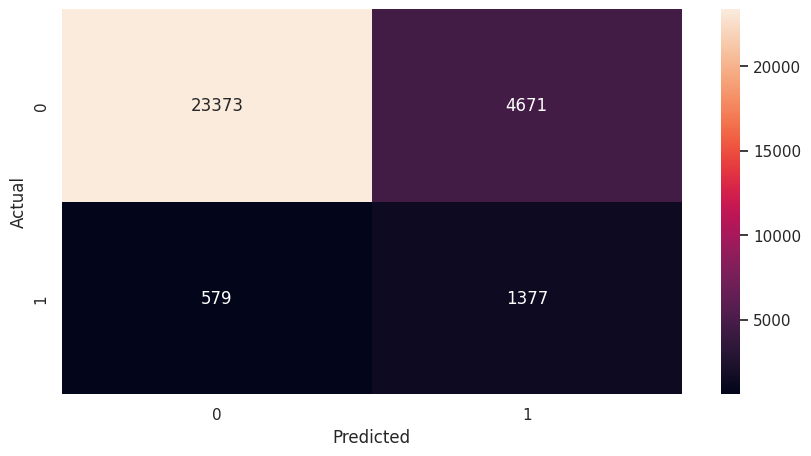

In [50]:
plt.figure(figsize=(10,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [51]:
# ROC curve
from sklearn.metrics import roc_curve, roc_auc_score


y_prob = XGmodel.predict_proba(x_test)[:, 1]  # Predict probabilities

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

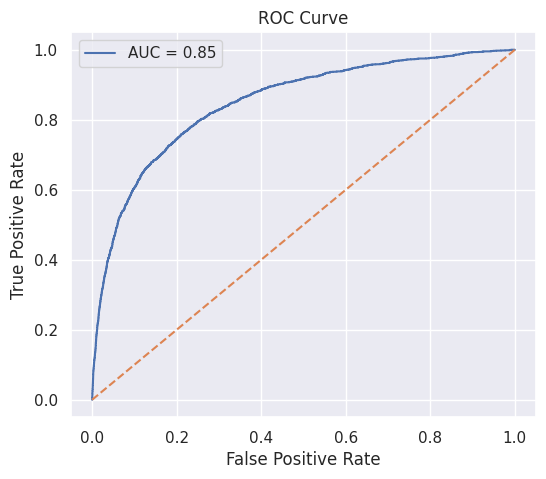

In [52]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

 My model AUC = 0.85

Model Results — XGBoost (scale_pos_weight=13.9): The baseline model with no imbalance handling caught only 20 out of 1,956 defaulters (Recall=0.01). XGBoost with scale_pos_weight improved this to 1,377 defaulters caught (Recall=0.70), with an AUC of 0.85 — meaning the model correctly ranks a random defaulter as higher risk than a random non-defaulter 85% of the time.

# SHAP ( xAI )

In [53]:
import shap
shap.initjs()   # To display ana initialize some of the SHAP plots

### Standard SHAP values

In [55]:
# get shap values
explainer = shap.Explainer(XGmodel)
shap_values = explainer(x_test)

In [56]:
shap_values.shape

(30000, 8)

**Waterfall plot**

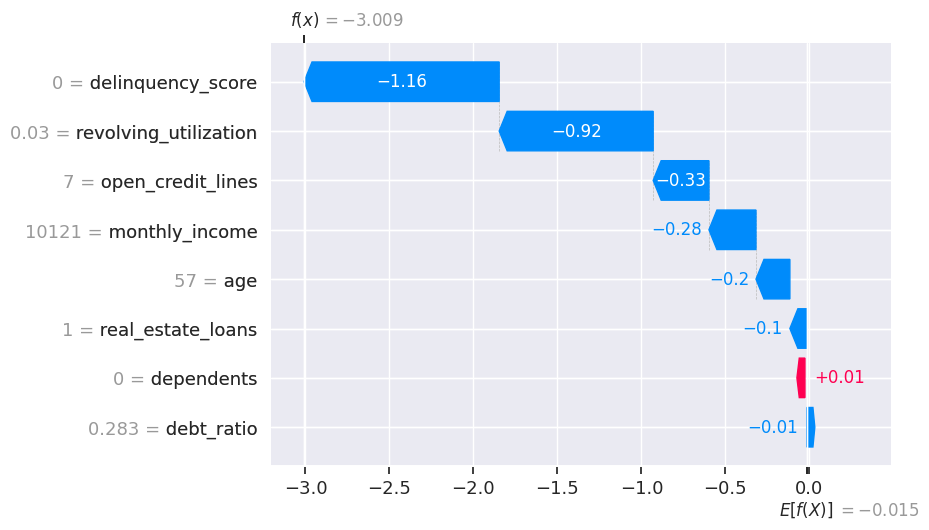

In [57]:
shap.plots.waterfall(shap_values[0])  # 1st customer

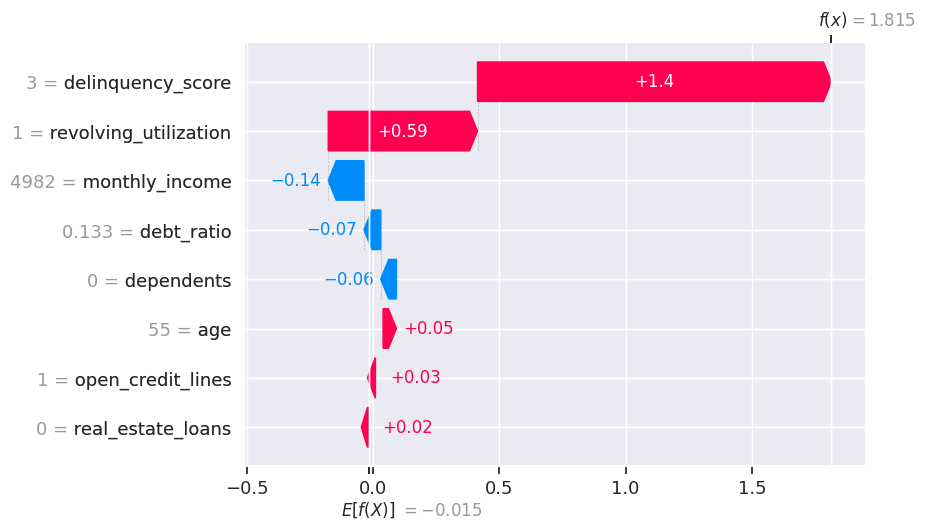

In [67]:
shap.plots.waterfall(shap_values[10])  # 10th customer ki vachina score

**Force plot**

In [69]:
shap.initjs()
shap.plots.force(shap_values[0])

**Stacked force plot**

In [71]:
shap.initjs()
shap.plots.force(shap_values[0:100])

**Absolute mean shap**

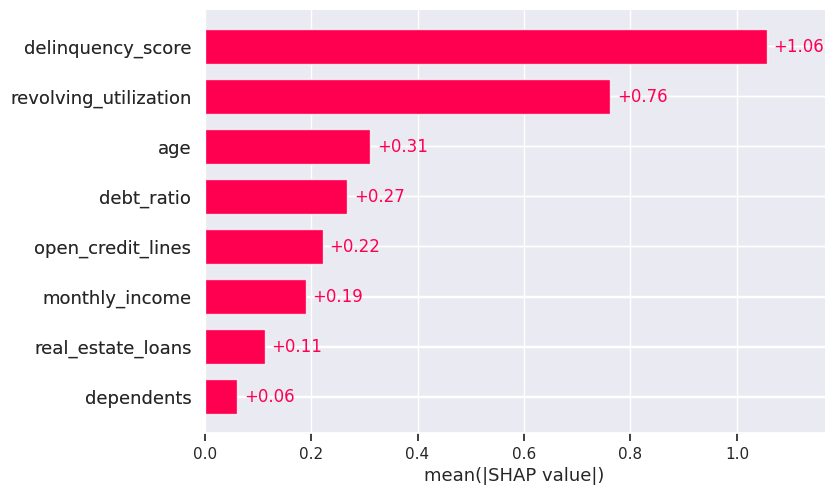

In [72]:
shap.plots.bar(shap_values)

**Beeswarm plot**

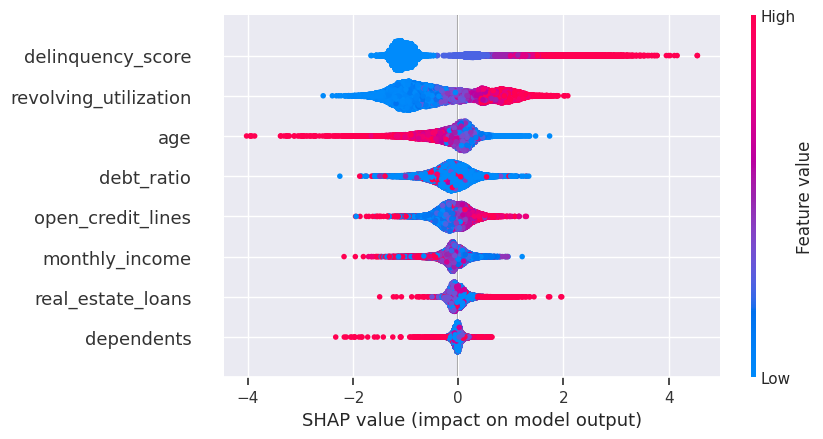

In [73]:
shap.plots.beeswarm(shap_values)

# Save Files

In [74]:
import joblib

In [75]:
joblib.dump(XGmodel, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [76]:
background = shap.maskers.Independent(x_train, max_samples=100)
explainer = shap.Explainer(XGmodel, background)
joblib.dump(explainer, "shap_explainer.pkl")

['shap_explainer.pkl']

In [79]:
feature_names = list(x.columns)
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']